In [3]:
with open("/content/drive/MyDrive/Ulibro transcripción.txt", "r", encoding="utf-8") as archivo:
    discurso = archivo.read()

print(discurso[:500])

¿Cuál construyó un relato íntimo sobre el amor, la pérdida y las huellas que deja el pasado en los lugares a los que siempre volvemos?

Yo leo esto y lo primero que pienso es que ustedes se tienen que conocer con María Carolina Hoyos Turbay muy pronto y preguntarte por qué las páginas de un libro se vuelven tal vez el refugio, o si se vuelven un refugio o un lugar seguro para hablar del amor, de la pérdida y de las huellas que deja el pasado en los lugares a los que siempre volvemos.

Hola, buen


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#calcular tamaño
len(discurso)

28977

In [6]:

discurso=discurso.lower()
discurso=discurso.replace(",","")
discurso=discurso.replace(";","")
discurso=discurso.replace(".","")
discurso=discurso.replace(":","")
discurso=discurso.replace('“',"")
len(discurso)


28242

In [7]:
#convertir en palabras
palabras=discurso.split()
palabras[:20]

['¿cuál',
 'construyó',
 'un',
 'relato',
 'íntimo',
 'sobre',
 'el',
 'amor',
 'la',
 'pérdida',
 'y',
 'las',
 'huellas',
 'que',
 'deja',
 'el',
 'pasado',
 'en',
 'los',
 'lugares']

In [8]:

import pandas as pd
import numpy as np

palabras_array=np.array(palabras)
len(palabras_array)

5124

In [9]:
#análisis de longitud de palabras
longitudes=np.array([len(palabra) for palabra in palabras_array])
print("Promedio: ",np.mean(longitudes))
print("Mediana: ",np.median(longitudes))
print("Minimo: ",np.min(longitudes))
print("Maximo", np.max(longitudes))

Promedio:  4.467213114754099
Mediana:  4.0
Minimo:  1
Maximo 18


In [10]:

#Generar un dataframe
df=pd.DataFrame(
    {
        "palabra":palabras,
        "longitud":longitudes
    }
)
#fun que me da los primeros 5 resultados
df.head()


,palabra,longitud
0,¿cuál,5
1,construyó,9
2,un,2
3,relato,6
4,íntimo,6


In [11]:

df["longitud"]=df["palabra"].str.len()
df.head(10)


,palabra,longitud
0,¿cuál,5
1,construyó,9
2,un,2
3,relato,6
4,íntimo,6
5,sobre,5
6,el,2
7,amor,4
8,la,2
9,pérdida,7


In [12]:
#frecuencia de palabras
#value_counts cuenta cuantas veces aparece el dato en el df
frecuencias=df["palabra"].value_counts()
print(frecuencias.head(20))

palabra
de      280
que     248
la      175
y       152
el      132
a       116
en      112
es       81
un       78
lo       60
una      57
no       54
como     53
por      47
se       45
con      42
del      41
los      41
este     37
me       37
Name: count, dtype: int64


In [13]:
#creo un arreglo de palabras a eliminar(stopwords)
stopwords = [
    "el","que","en","de","del","y","la","a","los","lo","al","“","un","te","es","se","no","si","le","su",'"',"por","o","son","eso","con","para","una","más","soy","así","las"
    ,"este","él","¿","?","esa"
]

In [14]:

#Filtrado
df_limpio=df[~df["palabra"].isin(stopwords)]
frecuencias=df_limpio["palabra"].value_counts()
frecuencias.head(20)

,count
palabra,
como,53
me,37
esta,34
libro,29
pero,24
creo,23
amor,22
mi,22
vida,21


In [15]:
from google.colab import files

uploaded = files.upload()

Saving imagen.jpg to imagen.jpg


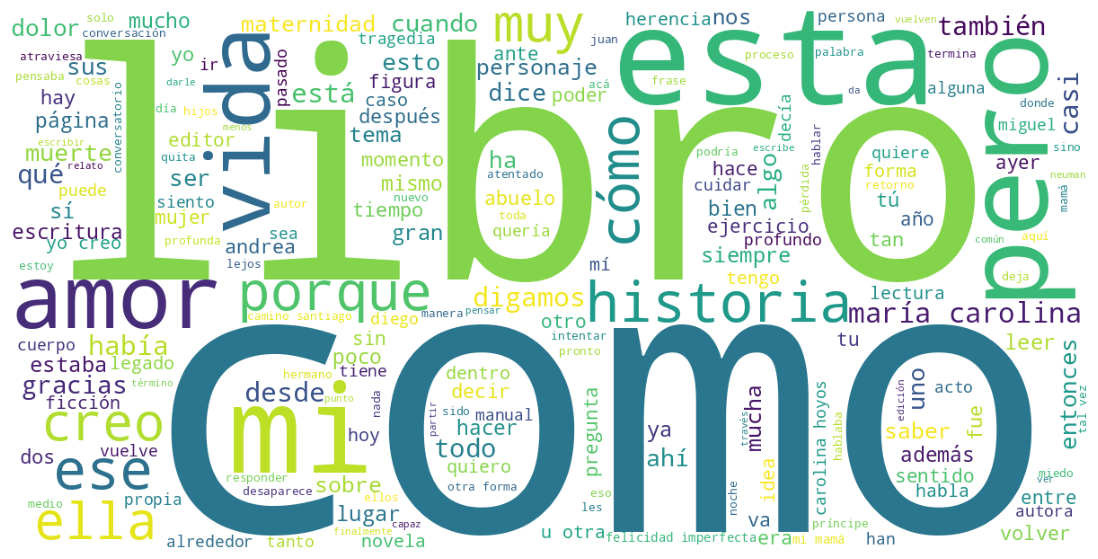

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

texto_limpio = " ".join(df_limpio["palabra"])


mascara = np.array(Image.open("imagen.jpg"))

nube=WordCloud(
  width=1200,
  height=600,
  background_color="white"
).generate(texto_limpio)

plt.figure(figsize=(15,7))
plt.imshow(nube)
plt.axis("off")
plt.show()